# Assignment 2, Part 2: Pedestrians on Eindhoven Centraal

In this notebook you model the future motion of pedestrians on platforms 3 and 4 of Eindhoven Centraal. Given the first 10 observed frames of a scene, you generate the remaining 20 frames for all pedestrians using conditional flow matching with time bundling.

You implement and compare two models:
1. a model with an uninformed Gaussian prior on the future velocities;
2. a model with an informed, data dependent prior.

The focus is not on model performance, but on an architecture that fits the problem formulation and on the comparison between the two priors. Every group member must be able to explain the model design and interpret the results. The full task description is in Section 2 of the assignment PDF.

In [2]:
%pip install gdown torch-geometric lightning pandas

  Using cached gdown-6.4.1-py3-none-any.whl.metadata (11 kB)
  Using cached beautifulsoup4-4.15.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached soupsieve-2.10-py3-none-any.whl.metadata (4.4 kB)
  Using cached PySocks-1.7.1-py3-none-any.whl.metadata (13 kB)
Using cached gdown-6.4.1-py3-none-any.whl (50 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 14.7 MB/s  0:00:00eta 0:00:01
Using cached beautifulsoup4-4.15.0-py3-none-any.whl (109 kB)
Using cached soupsieve-2.10-py3-none-any.whl (38 kB)
Using cached PySocks-1.7.1-py3-none-any.whl (16 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [gdown]32m4/5 [gdown]]
Note: you may need to restart the kernel to use updated packages.


In [3]:
import gdown
from pathlib import Path
import pickle
import torch
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from lightning import LightningDataModule, LightningModule, Trainer
import math
import warnings
import matplotlib.pyplot as plt
import numpy as np

/Users/filipprokes/Documents/GitHub/ml4sci-2026/ml4sci.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/filipprokes/Documents/GitHub/ml4sci-2026/ml4sci.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## Dataset

The dataset contains 100,000 samples. Each sample is a scene with 5 to 100 pedestrians, stored as an array of shape `(N, 30, 2)`: the 2D positions in metres of `N` pedestrians over 30 frames, spaced $\Delta t = 0.5$ s apart (15 s in total). Every pedestrian is present in all 30 frames.

The cell below downloads the data (about 290 MB).

In [4]:
drive_link = "https://drive.google.com/file/d/1sU_gti1xg2AB_SQINy_cZZm4jxE9lbIm/view?usp=drive_link"

DATA_PATH = Path("eindhoven_centraal.pkl")

if not DATA_PATH.exists():

    print("Downloading dataset...")

    gdown.download(
        url=drive_link,
        output=str(DATA_PATH),
        quiet=False,
    )

    print(
        "Download complete:",
        DATA_PATH,
    )

else:
    print(
        "Dataset already available:",
        DATA_PATH,
    )

Downloading...
From (original): https://drive.google.com/uc?id=1sU_gti1xg2AB_SQINy_cZZm4jxE9lbIm
From (redirected): https://drive.google.com/uc?id=1sU_gti1xg2AB_SQINy_cZZm4jxE9lbIm&confirm=t&uuid=45d92db1-d647-4e70-93d5-ee594f89674d
To: /Users/filipprokes/Documents/GitHub/ml4sci-2026/assignments/eindhoven_centraal.pkl
100%|██████████| 287M/287M [00:19<00:00, 14.5MB/s] 

Download complete: eindhoven_centraal.pkl


## Data loading and graph construction

`PedestriansDataset` loads the samples and turns each one into a graph:

* **Nodes** are pedestrians. The node features `x` are the full trajectories, with shape `(N, 30, 2)`.
* **Edges** are fixed over time: the same `edge_index` of shape `(2, E)` is used for every frame. The example graph is fully connected without self loops, so $E = N(N-1)$.

After batching with the PyG `DataLoader`, `x` has shape `(sum N, 30, 2)`, the edges of each scene are offset so they never connect different scenes, and `batch` gives the scene index of every pedestrian.

A fully connected graph grows with $N^2$ and connects pedestrians that are far apart and do not interact. You can and should implement a less connected graph in `make_edge_index`, for example a radius or k nearest neighbour graph. Such a graph may only be built from the observed frames 0 to 9, since the target frames are not available at inference.

`GraphDataModule` splits the samples randomly at sample level with a fixed seed, so no scene appears in more than one split. The test set must contain at least 1,000 samples; a larger test set is preferred. Normalization statistics must be computed on the training split only.

In [5]:
class PedestriansDataset(Dataset):
    """Pedestrian scenes as graphs with an edge connectivity that is fixed over time.

    Every sample is one scene with N pedestrians over F = 30 frames. Nodes are pedestrians
    and the node features are their full trajectories:
        x:          (N, F, 2)   positions in metres
        edge_index: (2, E)      edges between pedestrians, shared by all frames

    After batching with the PyG DataLoader:
        x:          (sum N, F, 2)
        edge_index: (2, sum E)  offset per scene, so edges never cross scenes
        batch:      (sum N,)    scene index of every pedestrian
    """

    def __init__(self, path, n_samples=None, T_cond=10, subset_seed=42):
        self.T_cond = T_cond
        self.raw_data = self._load_data(path)

        if n_samples is not None:
            if not 1 <= n_samples <= len(self.raw_data):
                raise ValueError(
                    "n_samples must be between 1 and the dataset size."
                )

            indices = torch.randperm(
                len(self.raw_data),
                generator=torch.Generator().manual_seed(subset_seed),
            )[:n_samples]

            self.raw_data = [
                self.raw_data[i] for i in indices.tolist()
            ]

        print(
            f"Using {len(self.raw_data)} samples; "
            f"subset seed={subset_seed}."
        )

    def _load_data(self, path):
        with open(path, "rb") as f:
            data = pickle.load(f)
        data = [torch.tensor(sample, dtype=torch.float32) for sample in data]
        print(
            f"\nLoaded {len(data)} samples from {path}, containing in total "
            f"{sum(x.shape[0] for x in data)} trajectories of {data[0].shape[1]} frames.\n"
        )
        return data

    def make_edge_index(self, sample):
        """Fully connected graph between N pedestrians, without self loops. Shape: (2, N * (N - 1))."""
        # NOTE: A fully connected graph grows with N^2 and also connects pedestrians that are far
        # apart and do not interact. A less connected graph can and should be implemented here,
        # for example a radius graph or a k nearest neighbour graph. To avoid leaking information
        # about the future, such a graph may only be built from the observed frames 0 to T_cond - 1.
        
        #Symmetric nearest-neighbour graph from the last observed frame.
        positions = sample[:, self.T_cond - 1, :]
        n = positions.shape[0]

        if n < 2:
            return torch.empty(
                (2, 0), dtype=torch.long, device=positions.device
            )

        k = min(8, n - 1)
        distances = torch.cdist(positions, positions)
        distances.fill_diagonal_(float("inf"))

        neighbours = distances.topk(
            k, dim=1, largest=False
        ).indices

        receivers = torch.arange(
            n, device=positions.device
        ).repeat_interleave(k)
        senders = neighbours.reshape(-1)

        edges = torch.stack([senders, receivers], dim=0)
        edges = torch.cat([edges, edges.flip(0)], dim=1)

        return torch.unique(edges, dim=1).contiguous() 

    def __len__(self):
        return len(self.raw_data)

    def __getitem__(self, idx):
        sample = self.raw_data[idx]  # (N, F, 2)
        N = sample.shape[0]
        return Data(x=sample, edge_index=self.make_edge_index(sample), num_nodes=N)


class GraphDataModule(LightningDataModule):
    """Random split at sample level, so no scene appears in more than one split."""

    def __init__(self, dataset, train_split, val_split, test_split, batch_size=8, seed=42, min_test_size=1000):
        super().__init__()
        if not math.isclose(train_split + val_split + test_split, 1.0):
            raise ValueError("train_split, val_split and test_split must sum to 1.")
        self.batch_size = batch_size
        self.seed = seed
        self.train_data, self.val_data, self.test_data = self.split_data(dataset, train_split, val_split)

        print(
            f"Split with seed {seed}: {len(self.train_data)} train, "
            f"{len(self.val_data)} validation, {len(self.test_data)} test samples."
        )
        if len(self.test_data) < min_test_size:
            warnings.warn(
                f"The test set contains {len(self.test_data)} samples, "
                f"but the assignment requires at least {min_test_size}."
            )

    def split_data(self, dataset, train_split, val_split):
        total_size = len(dataset)
        train_size = int(total_size * train_split)
        val_size = int(total_size * val_split)
        test_size = total_size - train_size - val_size

        return torch.utils.data.random_split(
            dataset,
            [train_size, val_size, test_size],
            generator=torch.Generator().manual_seed(self.seed),
        )

    def train_dataloader(self):
        return DataLoader(self.train_data, batch_size=self.batch_size, shuffle=True)  # type: ignore

    def val_dataloader(self):
        return DataLoader(self.val_data, batch_size=self.batch_size)  # type: ignore

    def test_dataloader(self):
        return DataLoader(self.test_data, batch_size=self.batch_size)  # type: ignore

    def predict_dataloader(self):
        return DataLoader(self.test_data, batch_size=self.batch_size)  # type: ignore

## Configuration

`n_samples` limits the number of samples for faster development. Make sure the final test set contains at least 1,000 samples, and report the seed and the size of each split.

In [6]:
T_cond = 10

n_samples = 10000  # Limit to a number of samples for faster training during development

dataset = PedestriansDataset(
    DATA_PATH, n_samples=n_samples, T_cond=T_cond
) 

data_module = GraphDataModule(
    dataset, train_split=0.7, val_split=0.1, test_split=0.2, batch_size=16
)


Loaded 100000 samples from eindhoven_centraal.pkl, containing in total 2358008 trajectories of 30 frames.

Using 10000 samples; subset seed=42.
Split with seed 42: 7000 train, 1000 validation, 2000 test samples.


In [7]:
#added by our group cell 
DT = 0.5
T_FUTURE = 20


@torch.no_grad()
def compute_velocity_stats(training_subset):
    total = torch.zeros(2, dtype=torch.float64)
    total_squared = torch.zeros(2, dtype=torch.float64)
    count = 0

    # Only training scenes contribute to normalization statistics.
    for index in training_subset.indices:
        positions = training_subset.dataset.raw_data[index].double()
        velocities = (
            positions[:, 1:] - positions[:, :-1]
        ) / DT
        velocities = velocities.reshape(-1, 2)

        total += velocities.sum(dim=0)
        total_squared += velocities.square().sum(dim=0)
        count += velocities.shape[0]

    if count == 0:
        raise ValueError("The training split is empty.")

    mean = total / count
    variance = (total_squared / count - mean.square()).clamp_min(0.0)
    std = variance.sqrt().clamp_min(1e-6)

    return mean.float(), std.float()


VELOCITY_MEAN, VELOCITY_STD = compute_velocity_stats(
    data_module.train_data
)

print("Velocity mean:", VELOCITY_MEAN)
print("Velocity standard deviation:", VELOCITY_STD)
print(
    "Split sizes:",
    len(data_module.train_data),
    len(data_module.val_data),
    len(data_module.test_data),
)

Velocity mean: tensor([ 0.0243, -0.0359])
Velocity standard deviation: tensor([0.2080, 0.7044])
Split sizes: 7000 1000 2000


In [8]:
#also added by our group cell

def normalize_velocity(velocity):
    mean = VELOCITY_MEAN.to(
        device=velocity.device,
        dtype=velocity.dtype,
    )
    std = VELOCITY_STD.to(
        device=velocity.device,
        dtype=velocity.dtype,
    )
    return (velocity - mean) / std


def denormalize_velocity(velocity_normalized):
    mean = VELOCITY_MEAN.to(
        device=velocity_normalized.device,
        dtype=velocity_normalized.dtype,
    )
    std = VELOCITY_STD.to(
        device=velocity_normalized.device,
        dtype=velocity_normalized.dtype,
    )
    return velocity_normalized * std + mean


def future_velocity_target(positions):
    # Include the displacement from observed frame 9 to future frame 10.
    return (
        positions[:, T_cond:T_cond + T_FUTURE]
        - positions[:, T_cond - 1:T_cond + T_FUTURE - 1]
    ) / DT


def velocities_to_positions(future_velocity, last_observed_position):
    return (
        last_observed_position[:, None, :]
        + DT * future_velocity.cumsum(dim=1)
    )


## Visualization
This method can be used to visualize the pedestrian trajectories. Use it to double check if your generated samples are realistic.

Make sure you download the background image: https://github.com/vlamen/ml4sci-2026/blob/main/assignments/Eindhoven_centraal_platform_3_4.png

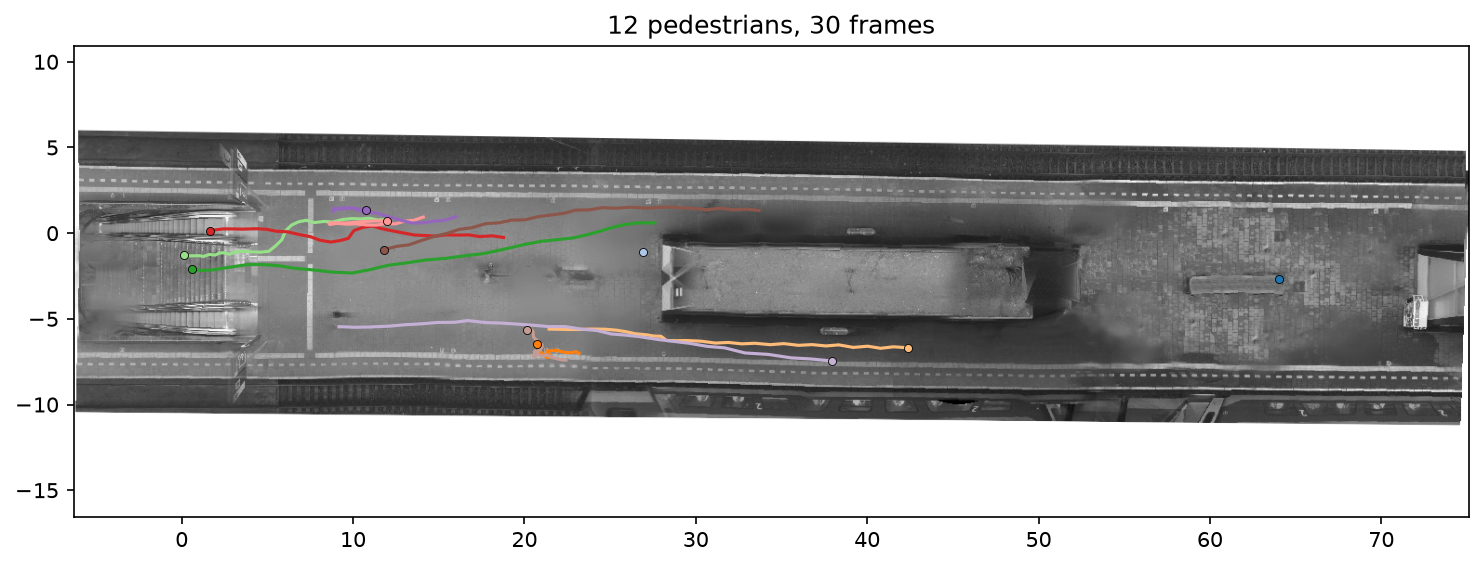

In [9]:
EXTENT = (-6.309, 75.091, -16.539, 10.909)  # (left, right, bottom, top) of the background image in metres


def plot_sample(sample, background_path="Eindhoven_centraal_platform_3_4.png", ax=None,
                cmap_name="tab20", figsize=(12, 4.5), dpi=150):
    """Plot all trajectories of one data sample on the station background.

    sample: (N, F, 2) positions of N pedestrians over F frames, as a numpy array or torch tensor.
    The x and y axes of the data are swapped to match the background image.
    Each pedestrian gets its own color; the dot marks the final position.
    """
    if isinstance(sample, torch.Tensor):
        sample = sample.detach().cpu().numpy()
    traj = np.asarray(sample)[..., [1, 0]]  # Swap x and y

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    else:
        fig = ax.figure

    ax.imshow(plt.imread(background_path), extent=EXTENT, origin="upper", zorder=0)
    ax.set_xlim(EXTENT[0], EXTENT[1])
    ax.set_ylim(EXTENT[2], EXTENT[3])

    cmap = plt.get_cmap(cmap_name)
    for i, t in enumerate(traj):
        color = cmap(i % cmap.N)
        ax.plot(t[:, 0], t[:, 1], color=color, lw=1.5, zorder=1)
        ax.scatter(t[-1, 0], t[-1, 1], color=color, s=15, edgecolors="black", linewidths=0.4, zorder=2)

    ax.set_title(f"{traj.shape[0]} pedestrians, {traj.shape[1]} frames")
    return fig, ax

plot_sample(dataset[0].x)
plt.show()

## Model architecture

Your model must capture patterns over **space**, the interactions between pedestrians, and over **time**, how the motion of each pedestrian evolves over the frames. As discussed in Practical 4, message passing handles space but not time, and flattening all frames into an MLP ignores temporal order and locality. Design an architecture that handles both axes, for example message passing over pedestrians combined with convolutions or attention over time.

Use the same architecture, training budget and sampler for both models, so that the prior is the only difference between them.

In [10]:
import torch.nn as nn


class PedestrianFlowNet(nn.Module):
    def __init__(self, hidden=64, n_blocks=3):
        super().__init__()
        self.history_encoder = nn.Sequential(
            nn.Conv1d(7, hidden, 3, padding=1),
            nn.SiLU(),
            nn.Conv1d(hidden, hidden, 3, padding=1),
            nn.SiLU(),
        )
        self.future_encoder = nn.Linear(3, hidden)
        self.flow_time_encoder = nn.Sequential(
            nn.Linear(1, hidden), nn.SiLU(), nn.Linear(hidden, hidden)
        )
        self.temporal_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(hidden, hidden, 3, padding=1),
                nn.SiLU(),
                nn.Conv1d(hidden, hidden, 3, padding=1),
            ) for _ in range(n_blocks)
        ])
        self.message_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(2 * hidden + 3, hidden),
                nn.SiLU(),
                nn.Linear(hidden, hidden),
            ) for _ in range(n_blocks)
        ])
        self.norms = nn.ModuleList([
            nn.LayerNorm(hidden) for _ in range(n_blocks)
        ])
        self.decoder = nn.Linear(hidden, 2)

    def forward(self, observed_positions, edge_index, scene_index, z, tau):
        # observed_positions: (N, 10, 2); z: (N, 20, 2).
        last = observed_positions[:, -1]
        relative = (observed_positions - last[:, None]) / 10.0
        absolute = observed_positions / 10.0
        observed_velocity = torch.diff(observed_positions, dim=1) / DT
        observed_velocity = normalize_velocity(observed_velocity)
        observed_velocity = torch.cat(
            [torch.zeros_like(observed_velocity[:, :1]), observed_velocity],
            dim=1,
        )
        history_time = torch.linspace(
            0, 1, T_cond, device=z.device, dtype=z.dtype
        )[None, :, None].expand(z.shape[0], -1, -1)
        history = torch.cat(
            [relative, absolute, observed_velocity, history_time], dim=-1
        )
        condition = self.history_encoder(history.transpose(1, 2)).mean(-1)
        future_time = torch.linspace(
            0, 1, T_FUTURE, device=z.device, dtype=z.dtype
        )[None, :, None].expand(z.shape[0], -1, -1)
        h = self.future_encoder(torch.cat([z, future_time], dim=-1))
        h = h + condition[:, None]
        h = h + self.flow_time_encoder(tau[:, None])[scene_index, None]

        senders, receivers = edge_index
        offset = (last[senders] - last[receivers]) / 10.0
        geometry = torch.cat([offset, offset.norm(dim=-1, keepdim=True)], -1)
        geometry = geometry[:, None].expand(-1, T_FUTURE, -1)
        degree = torch.bincount(receivers, minlength=z.shape[0]).clamp_min(1)
        for temporal, message, norm in zip(
            self.temporal_blocks, self.message_blocks, self.norms
        ):
            h = h + temporal(h.transpose(1, 2)).transpose(1, 2)
            messages = message(torch.cat(
                [h[senders], h[receivers], geometry], dim=-1
            ))
            aggregate = torch.zeros_like(h).index_add_(0, receivers, messages)
            h = norm(h + aggregate / degree[:, None, None])
        return self.decoder(h)

In [11]:
#added cell by us 
PRIOR_SIGMA = 1.0


def sample_velocity_prior(observed_positions, prior_kind, generator=None):
    shape = (observed_positions.shape[0], T_FUTURE, 2)
    noise = torch.randn(
        shape,
        device=observed_positions.device,
        dtype=observed_positions.dtype,
        generator=generator,
    ) * PRIOR_SIGMA

    if prior_kind == "uninformed":
        return noise

    if prior_kind == "informed":
        # Estimate current motion using only the last three observed steps.
        recent_velocity = (
            observed_positions[:, -1] - observed_positions[:, -4]
        ) / (3 * DT)
        prior_mean = normalize_velocity(recent_velocity)
        return prior_mean[:, None, :].expand(-1, T_FUTURE, -1) + noise

    raise ValueError(f"Unknown prior: {prior_kind}")


def flow_matching_loss(model, batch, prior_kind, generator=None):
    observed_positions = batch.x[:, :T_cond]
    target = normalize_velocity(future_velocity_target(batch.x))

    initial = sample_velocity_prior(
        observed_positions, prior_kind, generator=generator
    )
    tau = torch.rand(
        batch.num_graphs,
        device=batch.x.device,
        dtype=batch.x.dtype,
        generator=generator,
    )
    node_tau = tau[batch.batch][:, None, None]
    interpolated = (1.0 - node_tau) * initial + node_tau * target

    predicted_field = model(
        observed_positions,
        batch.edge_index,
        batch.batch,
        interpolated,
        tau,
    )

    # Give each scene equal weight despite different pedestrian counts.
    node_loss = (
        predicted_field - (target - initial)
    ).square().mean(dim=(1, 2))

    scene_loss = torch.zeros(
        batch.num_graphs,
        device=node_loss.device,
        dtype=node_loss.dtype,
    ).index_add_(0, batch.batch, node_loss)

    scene_size = torch.bincount(
        batch.batch, minlength=batch.num_graphs
    ).to(node_loss.dtype)

    return (scene_loss / scene_size).mean()

In [12]:
#extra cell added by us
torch.manual_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

check_batch = next(iter(data_module.train_dataloader())).to(DEVICE)
check_model = PedestrianFlowNet().to(DEVICE)

observed = check_batch.x[:, :T_cond]
noise = sample_velocity_prior(observed, "uninformed")
tau = torch.full(
    (check_batch.num_graphs,),
    0.5,
    device=DEVICE,
    dtype=check_batch.x.dtype,
)

# Every edge must stay within its own scene.
senders, receivers = check_batch.edge_index
assert torch.equal(
    check_batch.batch[senders],
    check_batch.batch[receivers],
)

with torch.no_grad():
    predicted = check_model(
        observed,
        check_batch.edge_index,
        check_batch.batch,
        noise,
        tau,
    )

assert predicted.shape == (
    check_batch.x.shape[0], T_FUTURE, 2
)
assert torch.isfinite(predicted).all()

# Check that target velocities reconstruct the true future positions.
target_velocity = future_velocity_target(check_batch.x)
reconstructed = velocities_to_positions(
    target_velocity, observed[:, -1]
)
assert torch.allclose(
    reconstructed,
    check_batch.x[:, T_cond:T_cond + T_FUTURE],
    rtol=1e-5,
    atol=1e-4,
)

for prior_kind in ["uninformed", "informed"]:
    check_model.zero_grad(set_to_none=True)
    loss = flow_matching_loss(check_model, check_batch, prior_kind)
    assert torch.isfinite(loss)
    loss.backward()

    gradients = [
        parameter.grad
        for parameter in check_model.parameters()
        if parameter.requires_grad
    ]
    assert all(
        gradient is not None and torch.isfinite(gradient).all()
        for gradient in gradients
    )
    print(f"{prior_kind}: loss = {loss.item():.4f}; gradients OK")

print("Batch scenes:", check_batch.num_graphs)
print("Output shape:", tuple(predicted.shape))
print("All checks passed.")

del check_model, check_batch, predicted, loss, gradients

Device: cpu
uninformed: loss = 2.7243; gradients OK
informed: loss = 2.5707; gradients OK
Batch scenes: 16
Output shape: (433, 20, 2)
All checks passed.


In [13]:
#another cell added by us

import time
import pandas as pd
from tqdm.auto import tqdm

PART2_CKPT_DIR = Path("part2_checkpoints")
PART2_CKPT_DIR.mkdir(exist_ok=True)

TRAIN_SEED = 42
TRAIN_STEPS = 1000
VALIDATE_EVERY = 250
LEARNING_RATE = 1e-3


@torch.no_grad()
def validation_flow_loss(model, prior_kind):
    model.eval()
    generator = torch.Generator(device=DEVICE).manual_seed(123)
    total = 0.0
    count = 0

    for batch in data_module.val_dataloader():
        batch = batch.to(DEVICE)
        loss = flow_matching_loss(
            model, batch, prior_kind, generator=generator
        )
        total += loss.item() * batch.num_graphs
        count += batch.num_graphs

    return total / count


def train_prior_model(prior_kind):
    # Reset initialization and training randomness equally for both models.
    torch.manual_seed(TRAIN_SEED)
    model = PedestrianFlowNet().to(DEVICE)
    generator = torch.Generator(device=DEVICE).manual_seed(TRAIN_SEED)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5
    )

    checkpoint_path = PART2_CKPT_DIR / f"{prior_kind}.pt"
    loader = data_module.train_dataloader()
    iterator = iter(loader)
    best_validation = float("inf")
    history = []
    running_loss = 0.0
    running_scenes = 0
    started = time.perf_counter()

    progress = tqdm(range(1, TRAIN_STEPS + 1), desc=prior_kind)
    for step in progress:
        try:
            batch = next(iterator)
        except StopIteration:
            iterator = iter(loader)
            batch = next(iterator)

        batch = batch.to(DEVICE)
        model.train()
        optimizer.zero_grad(set_to_none=True)
        loss = flow_matching_loss(
            model, batch, prior_kind, generator=generator
        )
        if not torch.isfinite(loss):
            raise RuntimeError(f"Nonfinite training loss at step {step}.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0, error_if_nonfinite=True
        )
        optimizer.step()

        running_loss += loss.item() * batch.num_graphs
        running_scenes += batch.num_graphs
        progress.set_postfix(loss=f"{loss.item():.4f}")

        if step % VALIDATE_EVERY == 0 or step == TRAIN_STEPS:
            validation = validation_flow_loss(model, prior_kind)
            if not math.isfinite(validation):
                raise RuntimeError("Nonfinite validation loss.")

            history.append({
                "step": step,
                "train_loss": running_loss / running_scenes,
                "val_loss": validation,
                "minutes": (time.perf_counter() - started) / 60,
            })
            running_loss = 0.0
            running_scenes = 0

            if validation < best_validation:
                best_validation = validation
                torch.save({
                    "model": model.state_dict(),
                    "prior_kind": prior_kind,
                    "prior_sigma": PRIOR_SIGMA,
                    "velocity_mean": VELOCITY_MEAN.cpu(),
                    "velocity_std": VELOCITY_STD.cpu(),
                    "step": step,
                    "val_loss": validation,
                    "seed": TRAIN_SEED,
                }, checkpoint_path)

            print(
                f"{prior_kind}: step {step}, "
                f"validation={validation:.4f}, "
                f"best={best_validation:.4f}"
            )

    history = pd.DataFrame(history)
    history.to_csv(
        PART2_CKPT_DIR / f"{prior_kind}_history.csv", index=False
    )

    checkpoint = torch.load(
        checkpoint_path, map_location=DEVICE, weights_only=True
    )
    model.load_state_dict(checkpoint["model"])
    model.eval()
    print(f"Loaded best {prior_kind} checkpoint: step {checkpoint['step']}")
    return model, history

## Part I: Uninformed Gaussian prior

Train a conditional flow matching model that generates the velocities of frames 10 to 29, conditioned on frames 0 to 9, using the independent coupling

$$\pi(x_0, x_1 \mid c) = p_0(x_0)\,p_1(x_1 \mid c), \qquad p_0 = \mathcal{N}(0, \sigma^2 I).$$

All 20 frames are generated in a single model call. Positions are recovered by summing the generated velocities, starting from the last observed position.

## Part II: Informed prior

Train a second model using a data dependent coupling

$$\pi(x_0, x_1 \mid c) = p_0(x_0 \mid c)\,p_1(x_1 \mid c).$$

The prior may only use the observed frames 0 to 9, so that $x_0 \perp x_1 \mid c$. It must remain stochastic and be sampled in the same way during training and inference.

## Evaluation

For every test sample, generate $M = 20$ futures with each model. All metrics are computed on frames 10 to 29 only.

**Pointwise metrics.** Report ADE, FDE, $\text{min}_{20}$ ADE and $\text{min}_{20}$ FDE. ADE and FDE are averaged over all pedestrians, samples and generated futures. For the $\text{min}_{20}$ metrics, the best future is selected per data sample based on the error averaged over all its pedestrians, not per pedestrian.

**Distributional metrics.** Plot histogram densities of the ground truth and both models for velocity magnitude, acceleration magnitude, tortuosity and distance to the closest neighbour within the same frame.

The exact definitions are given in the evaluation section of the assignment PDF. You are of course allowed to use code from the practicals

## Comparison

Show the four pointwise metrics for both models in a table, together with the four histograms. Explanations and interpretations of the results are written in Ans, not in this notebook.